<a href="https://colab.research.google.com/github/cristiangaymartin/tfm-estados-mercado/blob/main/notebooks/02_regimenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 · Detección de regímenes de mercado (HMM)

Detección no supervisada de estados de mercado sobre el S&P 500 mediante un
modelo oculto de Markov (HMM), usando rendimiento y volatilidad como variables.
Horizonte largo (histórico completo). Segunda etapa del análisis, tras `01_ingesta`.

In [1]:
%pip install hmmlearn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.0 MB/s eta 0:00:00


In [2]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hmmlearn import hmm
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

In [3]:
from google.colab import drive
drive.mount('/content/drive')

RUTA_DATOS = "/content/drive/MyDrive/TFM/data"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Leemos el CSV del S&P. index_col=0 y parse_dates para recuperar el índice de fechas.
sp = pd.read_csv(f"{RUTA_DATOS}/mercado_SP500.csv", index_col=0, parse_dates=True)

print("Forma:", sp.shape)
print("Rango:", sp.index.min().date(), "→", sp.index.max().date())
sp.head()

Forma: (9213, 3)
Rango: 1990-01-02 → 2026-08-03


,Close,ret_log,vol_21d
Date,,,
1990-01-02,359.690002,NaN,NaN
1990-01-03,358.760010,-0.002589,NaN
1990-01-04,355.670013,-0.008650,NaN
1990-01-05,352.200012,-0.009804,NaN
1990-01-08,353.790009,0.004504,NaN


In [5]:
# Nos quedamos con las dos features y eliminamos los NaN iniciales
datos_hmm = sp[["ret_log", "vol_21d"]].dropna()

print("Forma de los datos para el HMM:", datos_hmm.shape)
print("Rango:", datos_hmm.index.min().date(), "→", datos_hmm.index.max().date())
datos_hmm.head()

Forma de los datos para el HMM: (9192, 2)
Rango: 1990-01-31 → 2026-08-03


,ret_log,vol_21d
Date,,
1990-01-31,0.018710,0.010562
1990-02-01,-0.000882,0.010582
1990-02-02,0.006457,0.010773
1990-02-05,0.002806,0.010751
1990-02-06,-0.006621,0.010645


In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(datos_hmm)

print("Media tras estandarizar (debe ser ~0):", X.mean(axis=0).round(3))
print("Desviación tras estandarizar (debe ser ~1):", X.std(axis=0).round(3))

Media tras estandarizar (debe ser ~0): [-0. -0.]
Desviación tras estandarizar (debe ser ~1): [1. 1.]


In [7]:
modelo_hmm = hmm.GaussianHMM(
    n_components=3,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

modelo_hmm.fit(X)

print("¿Convergió el modelo?", modelo_hmm.monitor_.converged)

estados = modelo_hmm.predict(X)
datos_hmm["estado"] = estados

print("\nDistribución de días por estado:")
print(datos_hmm["estado"].value_counts().sort_index())

¿Convergió el modelo? True

Distribución de días por estado:
estado
0    3486
1    4030
2    1676
Name: count, dtype: int64


In [8]:
# Media de rendimiento y volatilidad reales en cada estado, más el nº de días
perfil = datos_hmm.groupby("estado").agg(
    ret_medio=("ret_log", "mean"),
    vol_media=("vol_21d", "mean"),
    dias=("ret_log", "size")
)

# Añadimos el % de días que representa cada estado
perfil["pct_dias"] = (100 * perfil["dias"] / perfil["dias"].sum()).round(1)

perfil.round({"ret_medio": 5, "vol_media": 4})

,ret_medio,vol_media,dias,pct_dias
estado,,,,
0,0.00045,0.0099,3486,37.9
1,0.00052,0.0057,4030,43.8
2,-0.00030,0.0190,1676,18.2


In [9]:
# Mapeo de estado numérico a nombre económico, según sus características
nombres_estados = {
    1: "Calma alcista",      # vol baja, rendimiento positivo
    0: "Normal",             # vol media
    2: "Estrés bajista",     # vol alta, rendimiento negativo
}

datos_hmm["regimen"] = datos_hmm["estado"].map(nombres_estados)

# Comprobamos el reparto con nombres
print(datos_hmm["regimen"].value_counts())

regimen
Calma alcista     4030
Normal            3486
Estrés bajista    1676
Name: count, dtype: int64


In [10]:
# Traemos el precio de cierre junto a los regímenes (alineados por fecha)
plot_df = datos_hmm.join(sp["Close"])

# Colores para cada régimen
colores = {
    "Calma alcista":  "#2ca02c",   # verde
    "Normal":         "#ff7f0e",   # naranja
    "Estrés bajista": "#d62728",   # rojo
}

print(plot_df[["Close", "regimen"]].head())

                 Close regimen
Date                          
1990-01-31  329.079987  Normal
1990-02-01  328.790009  Normal
1990-02-02  330.920013  Normal
1990-02-05  331.850006  Normal
1990-02-06  329.660004  Normal


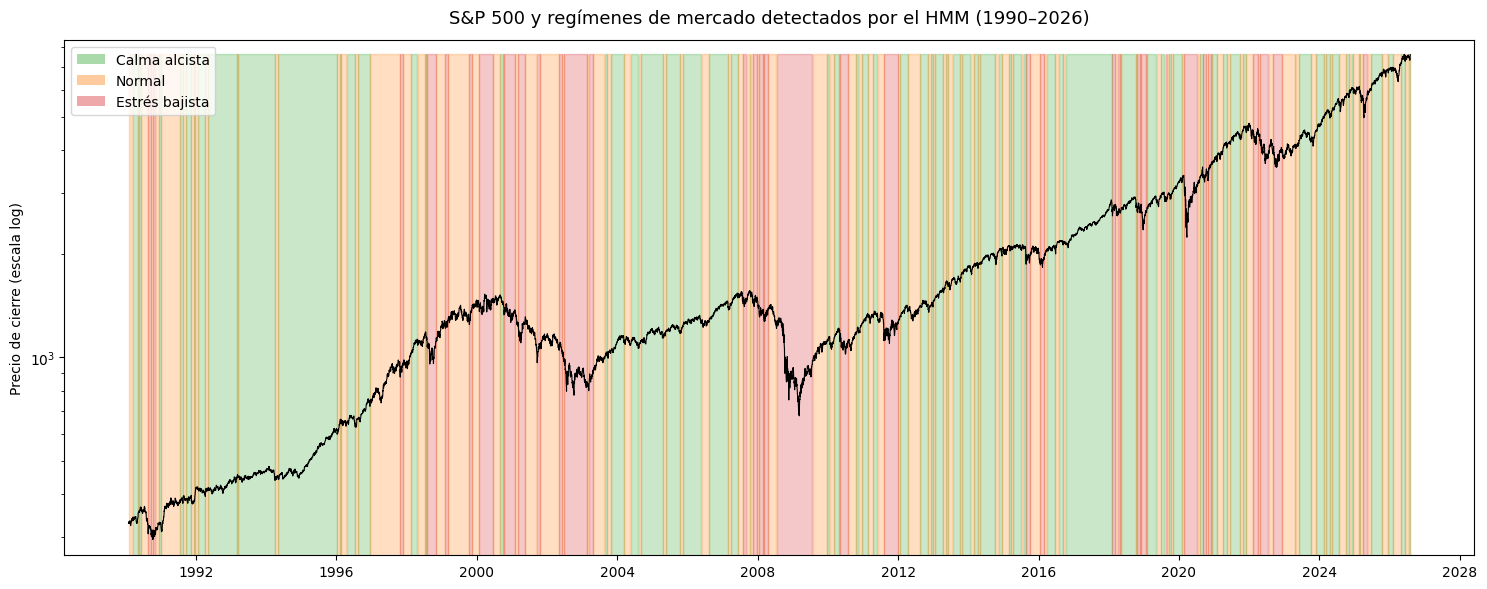

In [11]:
fig, ax = plt.subplots(figsize=(15, 6))

# Línea del precio (en gris, para que resalten los colores de fondo)
ax.plot(plot_df.index, plot_df["Close"], color="black", linewidth=0.8, zorder=3)

# Coloreamos el fondo según el régimen de cada día
for regimen, color in colores.items():
    mask = plot_df["regimen"] == regimen
    ax.fill_between(plot_df.index, 0, plot_df["Close"].max(),
                    where=mask, color=color, alpha=0.25, zorder=1)

ax.set_title("S&P 500 y regímenes de mercado detectados por el HMM (1990–2026)", fontsize=13, pad=12)
ax.set_ylabel("Precio de cierre (escala log)")
ax.set_yscale("log")   # escala logarítmica: los cambios % se ven proporcionales
ax.set_ylim(plot_df["Close"].min()*0.9, plot_df["Close"].max()*1.1)

# Leyenda manual
leyenda = [Patch(facecolor=c, alpha=0.4, label=r) for r, c in colores.items()]
ax.legend(handles=leyenda, loc="upper left")

plt.tight_layout()
RUTA_DOCS = "/content/drive/MyDrive/TFM/docs"
os.makedirs(RUTA_DOCS, exist_ok=True)

plt.savefig(f"{RUTA_DOCS}/regimenes_sp500.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Ventana del suavizado: nº de días a cada lado que se consideran.
# Una ventana de 11 (5 a cada lado + el día central) suele ser un buen punto de partida.
VENTANA = 11

# Filtro de mayoría: para cada día, el estado más frecuente en su ventana centrada
estado_suave = (
    datos_hmm["estado"]
    .rolling(window=VENTANA, center=True, min_periods=1)
    .apply(lambda x: x.mode()[0])   # mode()[0] = el valor más frecuente de la ventana
    .astype(int)
)

datos_hmm["estado_suave"] = estado_suave
datos_hmm["regimen_suave"] = datos_hmm["estado_suave"].map(nombres_estados)

# Comparamos cuántos cambios de régimen había antes y después
cambios_antes = (datos_hmm["estado"].diff() != 0).sum()
cambios_despues = (datos_hmm["estado_suave"].diff() != 0).sum()
print(f"Cambios de régimen ANTES del suavizado:   {cambios_antes}")
print(f"Cambios de régimen DESPUÉS del suavizado: {cambios_despues}")
print(f"Reducción: {100*(1 - cambios_despues/cambios_antes):.0f}%")

Cambios de régimen ANTES del suavizado:   202
Cambios de régimen DESPUÉS del suavizado: 194
Reducción: 4%


In [13]:
# La matriz de transición aprendida por el HMM
transmat = pd.DataFrame(
    modelo_hmm.transmat_,
    index=[f"desde {nombres_estados[i]}" for i in range(3)],
    columns=[f"a {nombres_estados[i]}" for i in range(3)]
)

transmat.round(3)

,a Normal,a Calma alcista,a Estrés bajista
desde Normal,0.969,0.021,0.010
desde Calma alcista,0.017,0.982,0.000
desde Estrés bajista,0.021,0.000,0.979


In [14]:
# Detectamos rachas: cada vez que el estado cambia, empieza una nueva racha
cambios = datos_hmm["estado"].diff().ne(0).cumsum()
duraciones = datos_hmm.groupby([cambios, "regimen"]).size()

# Duración media de las rachas por régimen
dur_media = duraciones.groupby(level="regimen").mean()
print("Duración media de cada régimen (días de mercado):")
print(dur_media.round(0))
print(f"\nNº total de rachas: {len(duraciones)}")
print(f"Duración media global: {duraciones.mean():.0f} días")

Duración media de cada régimen (días de mercado):
regimen
Calma alcista     59.0
Estrés bajista    49.0
Normal            35.0
dtype: float64

Nº total de rachas: 202
Duración media global: 46 días


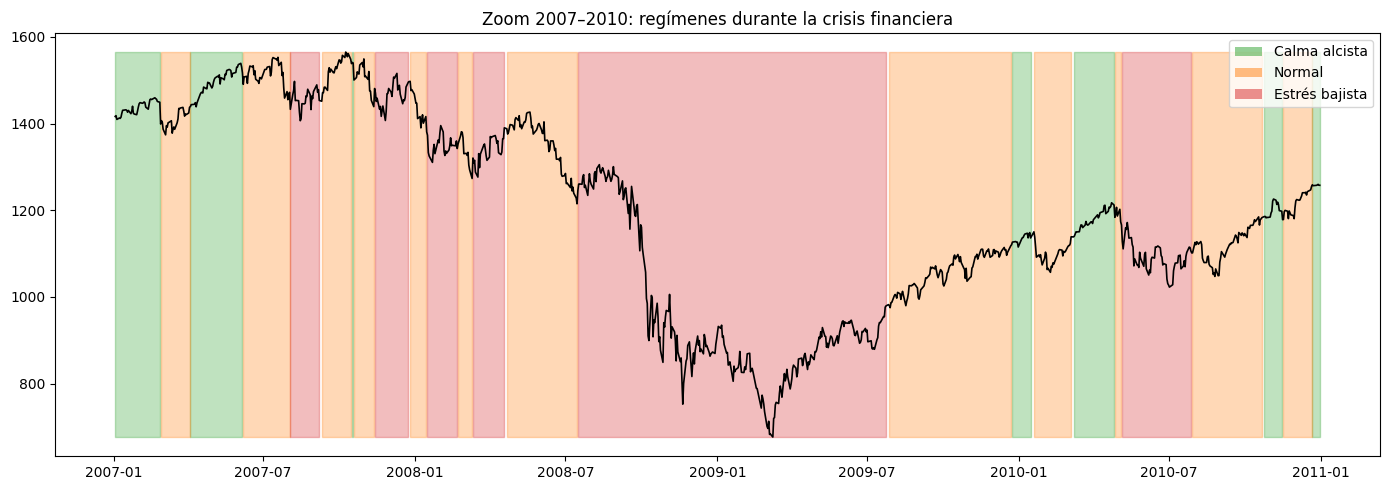

In [15]:
zoom = plot_df.loc["2007-01-01":"2010-12-31"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom.index, zoom["Close"], color="black", linewidth=1.2, zorder=3)
for regimen, color in colores.items():
    mask = zoom["regimen"] == regimen
    ax.fill_between(zoom.index, zoom["Close"].min(), zoom["Close"].max(),
                    where=mask, color=color, alpha=0.3, zorder=1)
ax.set_title("Zoom 2007–2010: regímenes durante la crisis financiera")
ax.legend(handles=[Patch(facecolor=c, alpha=0.5, label=r) for r, c in colores.items()], loc="upper right")
plt.tight_layout()
RUTA_DOCS = "/content/drive/MyDrive/TFM/docs"
os.makedirs(RUTA_DOCS, exist_ok=True)

plt.savefig(f"{RUTA_DOCS}/regimenes_sp500_zoom_2008.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
resultados = []

for n in [2, 3, 4, 5]:
    modelo = hmm.GaussianHMM(
        n_components=n,
        covariance_type="full",
        n_iter=1000,
        random_state=42
    )
    modelo.fit(X)

    # BIC del modelo (más bajo = mejor)
    bic = modelo.bic(X)
    # Log-verosimilitud (más alto = mejor ajuste bruto, sin penalizar complejidad)
    loglik = modelo.score(X)

    resultados.append({
        "n_estados": n,
        "log_verosimilitud": round(loglik, 0),
        "BIC": round(bic, 0),
        "convergio": modelo.monitor_.converged
    })

comparativa = pd.DataFrame(resultados)
print(comparativa.to_string(index=False))

 n_estados  log_verosimilitud     BIC  convergio
         2           -17951.0 36021.0       True
         3           -14020.0 28250.0       True
         4           -11642.0 23603.0       True
         5            -9482.0 19410.0       True


In [17]:
# Entrenamos el de 4 y vemos si sus estados son económicamente distinguibles
modelo_4 = hmm.GaussianHMM(n_components=4, covariance_type="full",
                           n_iter=1000, random_state=42)
modelo_4.fit(X)
estados_4 = modelo_4.predict(X)

datos_hmm["estado_4"] = estados_4
perfil_4 = datos_hmm.groupby("estado_4").agg(
    ret_medio=("ret_log", "mean"),
    vol_media=("vol_21d", "mean"),
    dias=("ret_log", "size")
)
perfil_4["pct_dias"] = (100 * perfil_4["dias"] / perfil_4["dias"].sum()).round(1)
print("Perfil del modelo de 4 estados:")
print(perfil_4.round({"ret_medio": 5, "vol_media": 4}))

Perfil del modelo de 4 estados:
          ret_medio  vol_media  dias  pct_dias
estado_4                                      
0           0.00055     0.0056  3763      40.9
1           0.00021     0.0128  1897      20.6
2           0.00033     0.0088  2661      28.9
3          -0.00022     0.0233   871       9.5


In [18]:
for n in [2, 5]:
    modelo_n = hmm.GaussianHMM(n_components=n, covariance_type="full",
                               n_iter=1000, random_state=42)
    modelo_n.fit(X)
    etiquetas = modelo_n.predict(X)

    tmp = datos_hmm[["ret_log", "vol_21d"]].copy()
    tmp["estado"] = etiquetas
    perfil = tmp.groupby("estado").agg(
        ret_medio=("ret_log", "mean"),
        vol_media=("vol_21d", "mean"),
        dias=("ret_log", "size")
    )
    perfil["pct_dias"] = (100 * perfil["dias"] / perfil["dias"].sum()).round(1)

    print(f"\n{'='*45}\nModelo de {n} estados:")
    print(perfil.sort_values("vol_media").round({"ret_medio": 5, "vol_media": 4}))


Modelo de 2 estados:
        ret_medio  vol_media  dias  pct_dias
estado                                      
1         0.00056     0.0067  5925      64.5
0        -0.00005     0.0152  3267      35.5

Modelo de 5 estados:
        ret_medio  vol_media  dias  pct_dias
estado                                      
0         0.00075     0.0045  1671      18.2
1         0.00037     0.0066  2471      26.9
2         0.00032     0.0091  2300      25.0
4         0.00027     0.0128  1877      20.4
3        -0.00029     0.0233   873       9.5


In [19]:
# Modelo definitivo: 4 estados
modelo_hmm = hmm.GaussianHMM(
    n_components=4,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)
modelo_hmm.fit(X)
print("¿Convergió?", modelo_hmm.monitor_.converged)

estados = modelo_hmm.predict(X)
datos_hmm["estado"] = estados

¿Convergió? True


In [20]:
# 1. Calculamos la volatilidad media de cada estado
vol_por_estado = datos_hmm.groupby("estado")["vol_21d"].mean().sort_values()

# 2. Ordenados de menor a mayor volatilidad, asignamos los nombres en orden
nombres_ordenados = ["Calma alcista", "Normal", "Corrección", "Crisis"]
nombres_estados = {
    estado_num: nombre
    for estado_num, nombre in zip(vol_por_estado.index, nombres_ordenados)
}

print("Mapeo asignado (estado → nombre), ordenado por volatilidad:")
for est, nom in nombres_estados.items():
    print(f"  estado {est} (vol media {vol_por_estado[est]:.4f}) → {nom}")

# 3. Aplicamos los nombres
datos_hmm["regimen"] = datos_hmm["estado"].map(nombres_estados)

Mapeo asignado (estado → nombre), ordenado por volatilidad:
  estado 0 (vol media 0.0056) → Calma alcista
  estado 2 (vol media 0.0088) → Normal
  estado 1 (vol media 0.0128) → Corrección
  estado 3 (vol media 0.0233) → Crisis


In [21]:
perfil_final = datos_hmm.groupby("regimen").agg(
    ret_medio=("ret_log", "mean"),
    vol_media=("vol_21d", "mean"),
    dias=("ret_log", "size")
)
perfil_final["pct_dias"] = (100 * perfil_final["dias"] / perfil_final["dias"].sum()).round(1)

# Ordenamos por volatilidad para leerlo como una escalera
perfil_final = perfil_final.sort_values("vol_media")
print(perfil_final.round({"ret_medio": 5, "vol_media": 4}))

               ret_medio  vol_media  dias  pct_dias
regimen                                            
Calma alcista    0.00055     0.0056  3763      40.9
Normal           0.00033     0.0088  2661      28.9
Corrección       0.00021     0.0128  1897      20.6
Crisis          -0.00022     0.0233   871       9.5


In [22]:
colores = {
    "Calma alcista": "#2ca02c",   # verde — todo va bien
    "Normal":        "#ffd92f",   # amarillo — neutro
    "Corrección":    "#ff7f0e",   # naranja — alerta
    "Crisis":        "#d62728",   # rojo — peligro
}

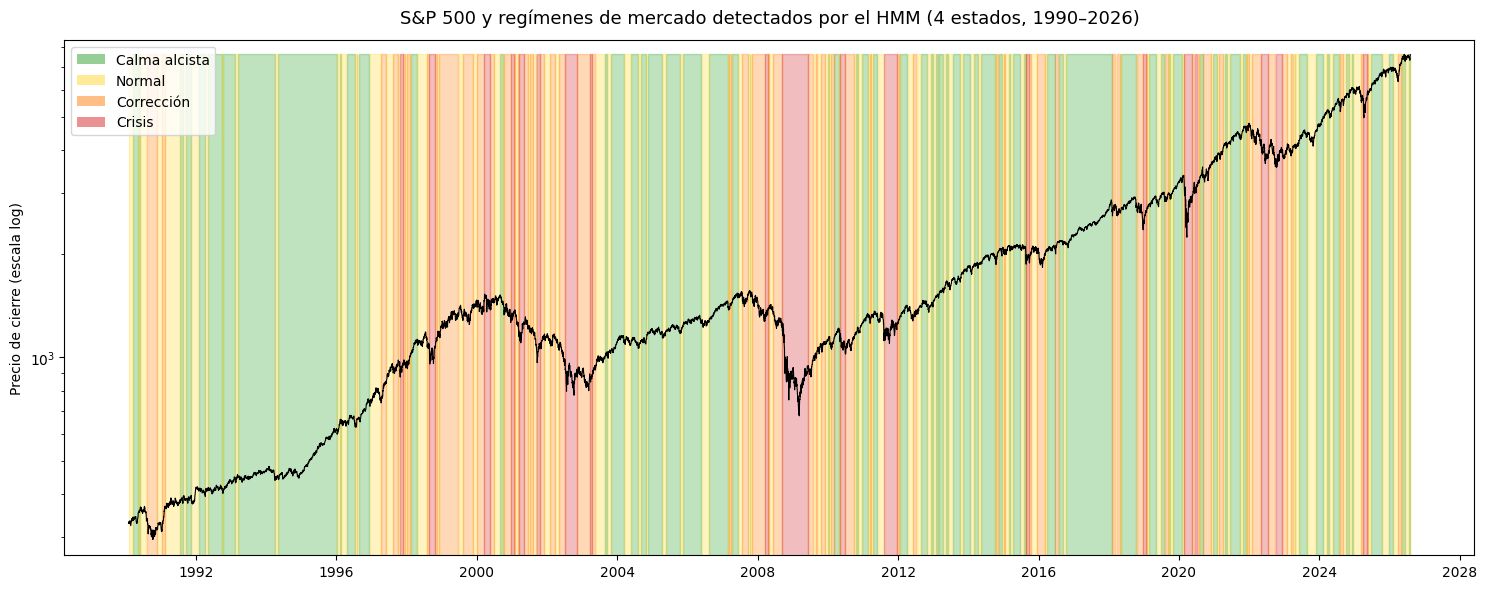

In [23]:
plot_df = datos_hmm.join(sp["Close"])

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(plot_df.index, plot_df["Close"], color="black", linewidth=0.8, zorder=3)
for regimen, color in colores.items():
    mask = plot_df["regimen"] == regimen
    ax.fill_between(plot_df.index, 0, plot_df["Close"].max(),
                    where=mask, color=color, alpha=0.30, zorder=1)
ax.set_title("S&P 500 y regímenes de mercado detectados por el HMM (4 estados, 1990–2026)", fontsize=13, pad=12)
ax.set_ylabel("Precio de cierre (escala log)")
ax.set_yscale("log")
ax.set_ylim(plot_df["Close"].min()*0.9, plot_df["Close"].max()*1.1)
ax.legend(handles=[Patch(facecolor=c, alpha=0.5, label=r) for r, c in colores.items()], loc="upper left")
plt.tight_layout()
plt.savefig(f"{RUTA_DOCS}/regimenes_sp500_4_estados.png", dpi=150, bbox_inches="tight")
plt.show()

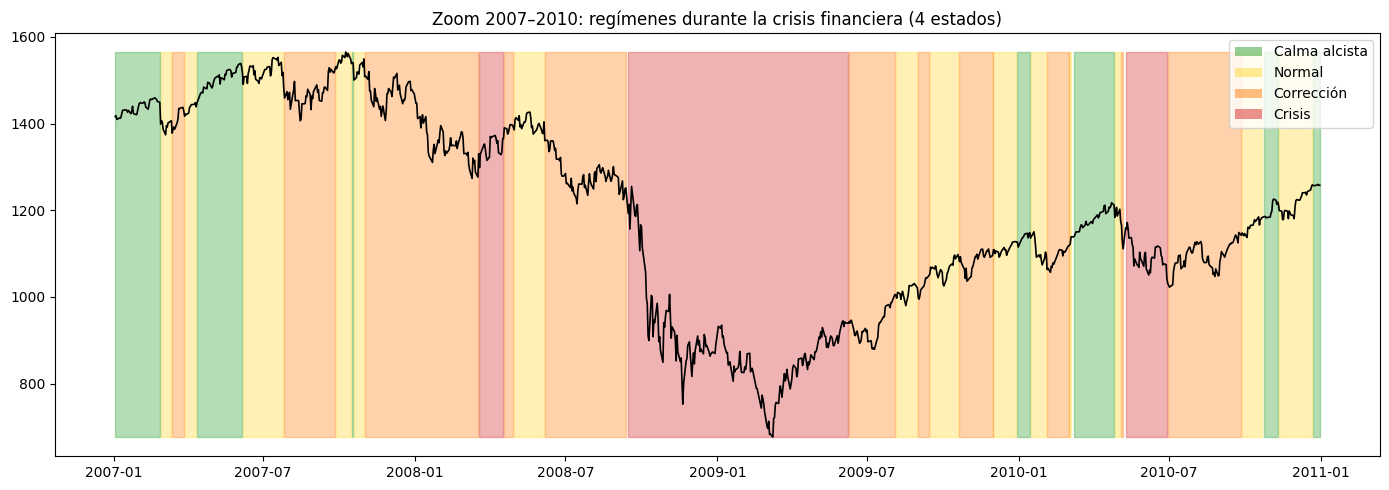

In [24]:
zoom = plot_df.loc["2007-01-01":"2010-12-31"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom.index, zoom["Close"], color="black", linewidth=1.2, zorder=3)
for regimen, color in colores.items():
    mask = zoom["regimen"] == regimen
    ax.fill_between(zoom.index, zoom["Close"].min(), zoom["Close"].max(),
                    where=mask, color=color, alpha=0.35, zorder=1)
ax.set_title("Zoom 2007–2010: regímenes durante la crisis financiera (4 estados)")
ax.legend(handles=[Patch(facecolor=c, alpha=0.5, label=r) for r, c in colores.items()], loc="upper right")
plt.tight_layout()
plt.savefig(f"{RUTA_DOCS}/regimenes_sp500_zoom_2008_4_estados.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
# 4 clusters, para comparar con los 4 estados del HMM
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)   # mismas variables estandarizadas que el HMM

datos_hmm["cluster"] = clusters

# Caracterizamos cada cluster (mismo enfoque que con los estados del HMM)
perfil_cluster = datos_hmm.groupby("cluster").agg(
    ret_medio=("ret_log", "mean"),
    vol_media=("vol_21d", "mean"),
    dias=("ret_log", "size")
)
perfil_cluster["pct_dias"] = (100 * perfil_cluster["dias"] / perfil_cluster["dias"].sum()).round(1)
perfil_cluster = perfil_cluster.sort_values("vol_media")
print("Perfil de los 4 clusters de K-Means (ordenados por volatilidad):")
print(perfil_cluster.round({"ret_medio": 5, "vol_media": 4}))

Perfil de los 4 clusters de K-Means (ordenados por volatilidad):
         ret_medio  vol_media  dias  pct_dias
cluster                                      
0          0.00060     0.0070  5944      64.7
1         -0.01486     0.0133  1458      15.9
2          0.01275     0.0138  1659      18.0
3          0.00064     0.0419   131       1.4


In [26]:
# Tabla de contingencia: cuántos días caen en cada combinación (régimen HMM × cluster K-Means)
tabla = pd.crosstab(datos_hmm["regimen"], datos_hmm["cluster"])
print("Días compartidos entre régimen HMM (filas) y cluster K-Means (columnas):")
print(tabla)

# Medida de acuerdo entre ambas particiones (0 = azar, 1 = idénticas)

ari = adjusted_rand_score(datos_hmm["estado"], datos_hmm["cluster"])
print(f"\nÍndice Rand ajustado (ARI) HMM vs K-Means: {ari:.3f}")

Días compartidos entre régimen HMM (filas) y cluster K-Means (columnas):
cluster           0    1    2    3
regimen                           
Calma alcista  3661   66   36    0
Corrección      406  658  833    0
Crisis            0  347  393  131
Normal         1877  387  397    0

Índice Rand ajustado (ARI) HMM vs K-Means: 0.320
